# 02 — Feature Engineering

**Objectif** : construire les timelines minute-par-minute et les métriques d'underperformance.

## Checklist
- [ ] Charger les données nettoyées
- [ ] Prototyper la timeline sur UN match
- [ ] Vérifier visuellement les features
- [ ] Construire toutes les timelines
- [ ] Créer les épisodes d'underperformance
- [ ] Sauvegarder

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.figsize': (14, 6),
    'figure.dpi': 100
})

print('Setup OK')

Setup OK


---
## 1. Charger les données nettoyées

In [4]:
shots = pd.read_parquet('../data/processed/shots_clean.parquet')
print(f"Dataset chargé : {shots.shape}")
print(f"Matchs : {shots['match_id'].nunique()}")
print(f"Tirs   : {len(shots)}")
shots.head()

Dataset chargé : (839, 26)
Matchs : 35
Tirs   : 839


,team,player,match_id,minute,second,game_minute,xg,shot_outcome,is_goal,shot_type,is_penalty,body_part,x,y,home_team,away_team,score_home,score_away,score_state,score_diff,period,competition_id,season_id,competition_name,season_name,source
0,Barcelona,Anssumane Fati,3773386,12,19,12.316667,0.200969,Off T,0,Open Play,0,Right Foot,108.6,28.0,Deportivo Alavés,Barcelona,0,0,drawing,0,1,11,90,Spain - La Liga,2020/2021,statsbomb
1,Deportivo Alavés,Edgar Antonio Méndez Ortega,3773386,16,7,16.116667,0.096384,Saved,0,Open Play,0,Right Foot,103.6,51.0,Deportivo Alavés,Barcelona,0,0,drawing,0,1,11,90,Spain - La Liga,2020/2021,statsbomb
2,Barcelona,Antoine Griezmann,3773386,19,42,19.700000,0.098879,Off T,0,Open Play,0,Left Foot,104.3,33.9,Deportivo Alavés,Barcelona,0,0,drawing,0,1,11,90,Spain - La Liga,2020/2021,statsbomb
3,Barcelona,Lionel Andrés Messi Cuccittini,3773386,22,26,22.433333,0.078938,Blocked,0,Free Kick,0,Left Foot,97.9,44.3,Deportivo Alavés,Barcelona,0,0,drawing,0,1,11,90,Spain - La Liga,2020/2021,statsbomb
4,Deportivo Alavés,Luis Jesús Rioja González,3773386,30,6,30.100000,0.976192,Goal,1,Open Play,0,Left Foot,118.3,42.1,Deportivo Alavés,Barcelona,0,0,drawing,0,1,11,90,Spain - La Liga,2020/2021,statsbomb


---
## 2. Prototyper sur UN match

Avant de lancer sur tout le dataset, on construit la timeline d'un seul match et on vérifie visuellement que tout est cohérent.

In [5]:
from src.features import UnderperformanceFeatures

feat = UnderperformanceFeatures()

# Choisir un match avec beaucoup de tirs (intéressant pour le prototype)
shots_per_match = shots.groupby('match_id').size().sort_values(ascending=False)
test_match_id = shots_per_match.index[0]
test_shots = shots[shots['match_id'] == test_match_id]

teams = test_shots['team'].unique()
n_shots = len(test_shots)
n_goals = test_shots['is_goal'].sum()

print(f"Match sélectionné : {teams[0]} vs {teams[1]}")
print(f"Tirs : {n_shots}, Buts : {n_goals}")
print(f"\nDétail des tirs :")
test_shots[['team', 'game_minute', 'xg', 'is_goal', 'shot_outcome', 'score_state']].head(20)

Match sélectionné : Valencia vs Barcelona
Tirs : 35, Buts : 4

Détail des tirs :


,team,game_minute,xg,is_goal,shot_outcome,score_state
330,Valencia,2.683333,0.022516,0,Off T,drawing
331,Barcelona,19.200000,0.024988,0,Blocked,drawing
332,Valencia,20.283333,0.027199,0,Off T,drawing
333,Valencia,25.766667,0.157820,0,Blocked,drawing
334,Valencia,28.200000,0.065085,0,Saved,drawing
335,Valencia,28.866667,0.220578,1,Goal,drawing
336,Barcelona,30.483333,0.016244,0,Off T,losing
337,Valencia,32.250000,0.030818,0,Blocked,winning
338,Valencia,32.316667,0.036865,0,Blocked,winning
339,Barcelona,32.516667,0.082939,0,Saved,losing


In [7]:
# Construire la timeline de ce match
test_timeline = feat.build_match_timeline(test_shots)
print(f"Timeline shape : {test_timeline.shape}")
print(f"Colonnes : {list(test_timeline.columns)}")
test_timeline.head(10)

Timeline shape : (176, 40)
Colonnes : ['match_id', 'team', 'opponent', 'is_home', 'minute', 'cum_xg', 'cum_goals', 'cum_underperf', 'cum_shots', 'score_diff', 'score_state', 'shots_since_last_goal', 'xg_since_last_goal', 'rolling_xg_5min', 'rolling_goals_5min', 'rolling_shots_5min', 'rolling_underperf_5min', 'rolling_xg_10min', 'rolling_goals_10min', 'rolling_shots_10min', 'rolling_underperf_10min', 'rolling_xg_15min', 'rolling_goals_15min', 'rolling_shots_15min', 'rolling_underperf_15min', 'future_xga_5min', 'future_goals_against_5min', 'future_opp_shots_5min', 'future_conceded_5min', 'future_window_complete_5min', 'future_xga_10min', 'future_goals_against_10min', 'future_opp_shots_10min', 'future_conceded_10min', 'future_window_complete_10min', 'future_xga_15min', 'future_goals_against_15min', 'future_opp_shots_15min', 'future_conceded_15min', 'future_window_complete_15min']


,match_id,team,opponent,is_home,minute,cum_xg,cum_goals,cum_underperf,cum_shots,score_diff,score_state,shots_since_last_goal,xg_since_last_goal,rolling_xg_5min,rolling_goals_5min,rolling_shots_5min,rolling_underperf_5min,rolling_xg_10min,rolling_goals_10min,rolling_shots_10min,rolling_underperf_10min,rolling_xg_15min,rolling_goals_15min,rolling_shots_15min,rolling_underperf_15min,future_xga_5min,future_goals_against_5min,future_opp_shots_5min,future_conceded_5min,future_window_complete_5min,future_xga_10min,future_goals_against_10min,future_opp_shots_10min,future_conceded_10min,future_window_complete_10min,future_xga_15min,future_goals_against_15min,future_opp_shots_15min,future_conceded_15min,future_window_complete_15min
0,3773377,Valencia,Barcelona,0,1,0.000000,0,0.000000,0,0,drawing,0,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0.000000,0.0,0,0,0,1,0.000000,0,0,0,1,0.000000,0,0,0,1
1,3773377,Valencia,Barcelona,0,2,0.000000,0,0.000000,0,0,drawing,0,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0.000000,0.0,0,0,0,1,0.000000,0,0,0,1,0.000000,0,0,0,1
2,3773377,Valencia,Barcelona,0,3,0.022516,0,0.022516,1,0,drawing,1,0.022516,0.022516,0,1,0.022516,0.022516,0,1,0.022516,0.022516,0,1,0.022516,0.0,0,0,0,1,0.000000,0,0,0,1,0.000000,0,0,0,1
3,3773377,Valencia,Barcelona,0,4,0.022516,0,0.022516,1,0,drawing,1,0.022516,0.022516,0,1,0.022516,0.022516,0,1,0.022516,0.022516,0,1,0.022516,0.0,0,0,0,1,0.000000,0,0,0,1,0.000000,0,0,0,1
4,3773377,Valencia,Barcelona,0,5,0.022516,0,0.022516,1,0,drawing,1,0.022516,0.022516,0,1,0.022516,0.022516,0,1,0.022516,0.022516,0,1,0.022516,0.0,0,0,0,1,0.000000,0,0,0,1,0.024988,0,1,0,1
5,3773377,Valencia,Barcelona,0,6,0.022516,0,0.022516,1,0,drawing,1,0.022516,0.022516,0,1,0.022516,0.022516,0,1,0.022516,0.022516,0,1,0.022516,0.0,0,0,0,1,0.000000,0,0,0,1,0.024988,0,1,0,1
6,3773377,Valencia,Barcelona,0,7,0.022516,0,0.022516,1,0,drawing,1,0.022516,0.022516,0,1,0.022516,0.022516,0,1,0.022516,0.022516,0,1,0.022516,0.0,0,0,0,1,0.000000,0,0,0,1,0.024988,0,1,0,1
7,3773377,Valencia,Barcelona,0,8,0.022516,0,0.022516,1,0,drawing,1,0.022516,0.000000,0,0,0.000000,0.022516,0,1,0.022516,0.022516,0,1,0.022516,0.0,0,0,0,1,0.000000,0,0,0,1,0.024988,0,1,0,1
8,3773377,Valencia,Barcelona,0,9,0.022516,0,0.022516,1,0,drawing,1,0.022516,0.000000,0,0,0.000000,0.022516,0,1,0.022516,0.022516,0,1,0.022516,0.0,0,0,0,1,0.000000,0,0,0,1,0.024988,0,1,0,1
9,3773377,Valencia,Barcelona,0,10,0.022516,0,0.022516,1,0,drawing,1,0.022516,0.000000,0,0,0.000000,0.022516,0,1,0.022516,0.022516,0,1,0.022516,0.0,0,0,0,1,0.024988,0,1,0,1,0.024988,0,1,0,1


---
## 3. Vérification visuelle du match prototype

**C'est l'étape la plus importante de cette phase.** On vérifie que :
- Le xG cumulé monte correctement
- L'underperformance = xG - buts est cohérente
- Le score_state change bien quand un but est marqué
- Les fenêtres futures sont calculées correctement

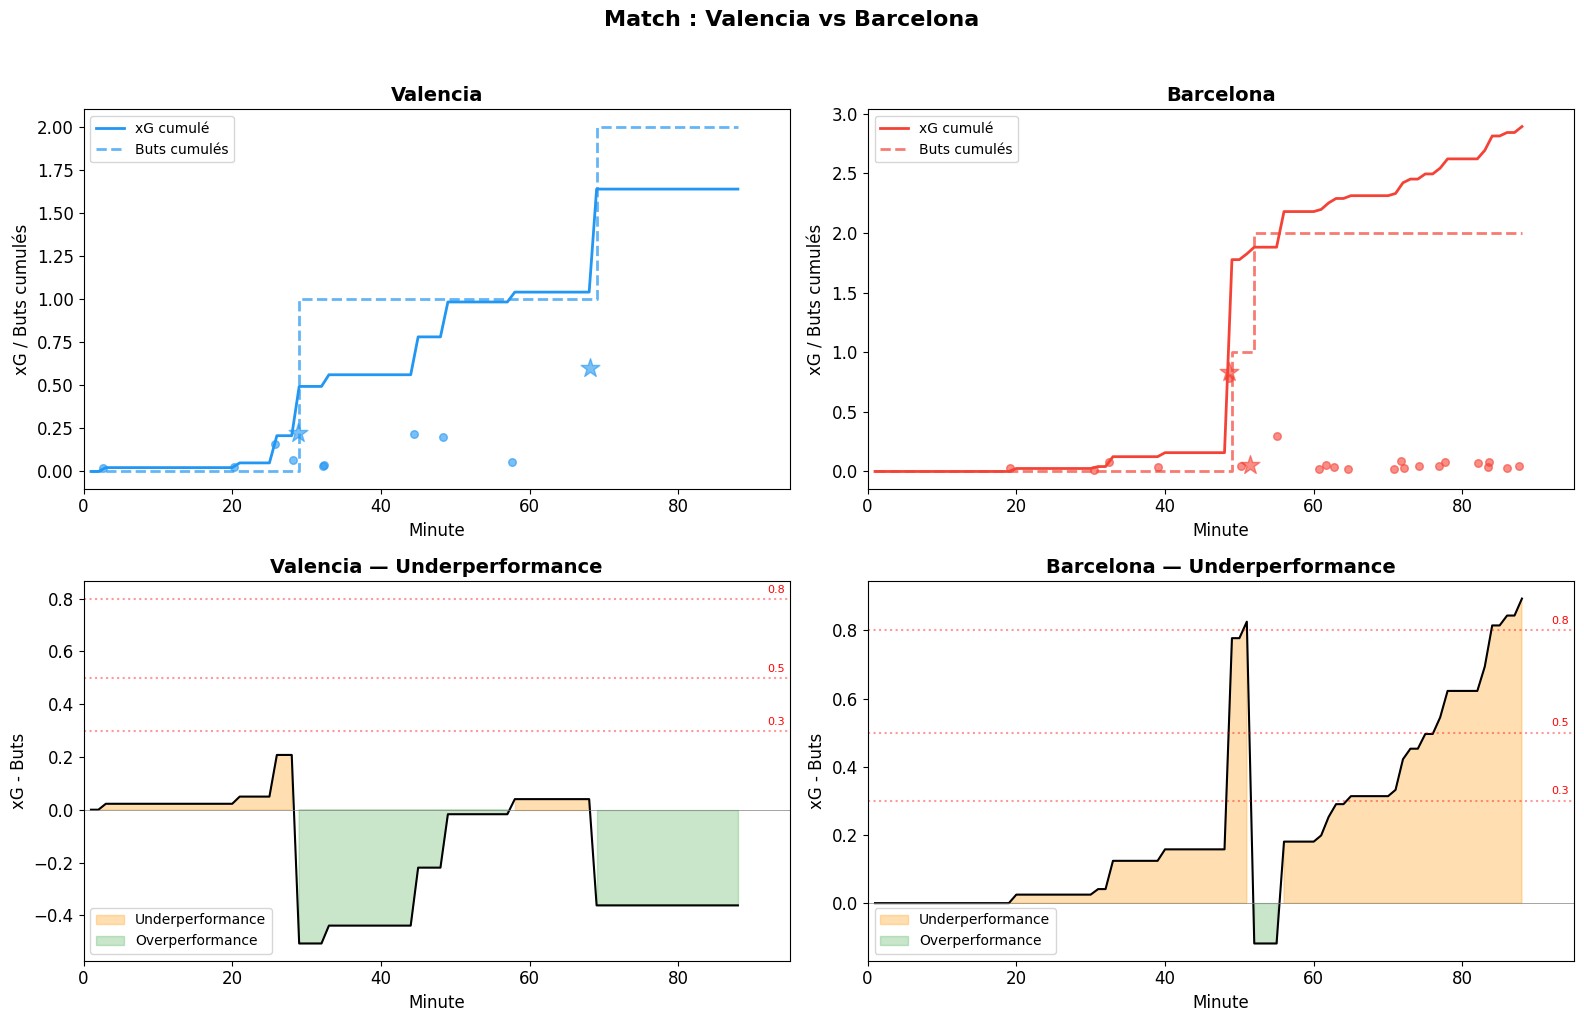

In [8]:
# === VISUALISATION 1 : xG cumulé et underperformance ===

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, team in enumerate(teams):
    team_tl = test_timeline[test_timeline['team'] == team]
    team_shots_only = test_shots[test_shots['team'] == team]
    color = '#2196F3' if i == 0 else '#F44336'
    
    # Panel A : xG cumulé vs buts
    ax = axes[0, i]
    ax.plot(team_tl['minute'], team_tl['cum_xg'], 
            color=color, linewidth=2, label='xG cumulé')
    ax.step(team_tl['minute'], team_tl['cum_goals'], 
            color=color, linewidth=2, linestyle='--', 
            alpha=0.7, label='Buts cumulés', where='post')
    
    # Marquer les tirs
    for _, shot in team_shots_only.iterrows():
        marker = 'o' if shot['is_goal'] == 0 else '*'
        size = 30 if shot['is_goal'] == 0 else 200
        ax.scatter(shot['game_minute'], shot['xg'], 
                   c=color, s=size, marker=marker, 
                   zorder=5, alpha=0.6)
    
    ax.set_title(f"{team}")
    ax.set_xlabel('Minute')
    ax.set_ylabel('xG / Buts cumulés')
    ax.legend(fontsize=10)
    ax.set_xlim(0, 95)
    
    # Panel B : Underperformance cumulative
    ax2 = axes[1, i]
    ax2.fill_between(team_tl['minute'], 0, team_tl['cum_underperf'],
                     where=team_tl['cum_underperf'] >= 0,
                     color='#FF9800', alpha=0.3, label='Underperformance')
    ax2.fill_between(team_tl['minute'], 0, team_tl['cum_underperf'],
                     where=team_tl['cum_underperf'] < 0,
                     color='#4CAF50', alpha=0.3, label='Overperformance')
    ax2.plot(team_tl['minute'], team_tl['cum_underperf'], 
             color='black', linewidth=1.5)
    ax2.axhline(0, color='gray', linestyle='-', linewidth=0.5)
    
    # Seuils
    for thresh in [0.3, 0.5, 0.8]:
        ax2.axhline(thresh, color='red', linestyle=':', alpha=0.4)
        ax2.text(92, thresh + 0.02, f'{thresh}', fontsize=8, color='red')
    
    ax2.set_title(f"{team} — Underperformance")
    ax2.set_xlabel('Minute')
    ax2.set_ylabel('xG - Buts')
    ax2.legend(fontsize=10)
    ax2.set_xlim(0, 95)

plt.suptitle(f"Match : {teams[0]} vs {teams[1]}",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/02_prototype_match.png', 
            dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# === VÉRIFICATION 2 : Score state ===
# Le score state doit changer exactement quand un but est marqué

team = teams[0]
team_tl = test_timeline[test_timeline['team'] == team]
team_shots_only = test_shots[test_shots['team'] == team]
goals = team_shots_only[team_shots_only['is_goal'] == 1]

print(f"=== Vérification score state pour {team} ===")
print(f"\nButs marqués par {team} :")
for _, g in goals.iterrows():
    print(f"  Minute {g['game_minute']:.1f}")

print(f"\nTransitions de score_state :")
prev_state = None
for _, row in team_tl.iterrows():
    if row['score_state'] != prev_state:
        print(f"  Minute {int(row['minute']):3d} → {row['score_state']} "
              f"(diff={int(row['score_diff'])})")
        prev_state = row['score_state']

=== Vérification score state pour Valencia ===

Buts marqués par Valencia :
  Minute 28.9
  Minute 68.2

Transitions de score_state :
  Minute   1 → drawing (diff=0)
  Minute  29 → winning (diff=1)
  Minute  49 → drawing (diff=0)
  Minute  52 → losing (diff=-1)
  Minute  69 → drawing (diff=0)


In [10]:
# === VÉRIFICATION 3 : Fenêtres futures ===
# Vérifier que future_xga_10min à la minute 30 correspond bien
# aux tirs adverses entre minute 30 et 40

check_minute = 30
team = teams[0]
opponent = teams[1]

team_tl = test_timeline[test_timeline['team'] == team]
row_at_30 = team_tl[team_tl['minute'] == check_minute].iloc[0]

# Calcul manuel
opp_shots_30_40 = test_shots[
    (test_shots['team'] == opponent) &
    (test_shots['game_minute'] > check_minute) &
    (test_shots['game_minute'] <= check_minute + 10)
]
manual_xga = opp_shots_30_40['xg'].sum()
manual_shots = len(opp_shots_30_40)
manual_goals = opp_shots_30_40['is_goal'].sum()

print(f"=== Vérification fenêtre future à la minute {check_minute} ===")
print(f"Équipe : {team}, Adversaire : {opponent}")
print(f"")
print(f"{'Métrique':<30} {'Pipeline':>10} {'Manuel':>10} {'OK':>5}")
print("-" * 58)

checks = [
    ('future_xga_10min', row_at_30['future_xga_10min'], manual_xga),
    ('future_opp_shots_10min', row_at_30['future_opp_shots_10min'], manual_shots),
    ('future_goals_against_10min', row_at_30['future_goals_against_10min'], manual_goals),
]

all_ok = True
for name, pipeline_val, manual_val in checks:
    ok = abs(pipeline_val - manual_val) < 0.001
    all_ok = all_ok and ok
    status = '✅' if ok else '❌'
    print(f"{name:<30} {pipeline_val:>10.4f} {manual_val:>10.4f} {status:>5}")

print(f"\n{'Toutes les vérifications passent !' if all_ok else '⚠️ ERREUR DÉTECTÉE'}")

=== Vérification fenêtre future à la minute 30 ===
Équipe : Valencia, Adversaire : Barcelona

Métrique                         Pipeline     Manuel    OK
----------------------------------------------------------
future_xga_10min                   0.1328     0.1328     ✅
future_opp_shots_10min             3.0000     3.0000     ✅
future_goals_against_10min         0.0000     0.0000     ✅

Toutes les vérifications passent !


In [12]:
# === VÉRIFICATION 4 : Pas de look-ahead bias ===
# cum_xg à la minute t ne doit utiliser que les tirs jusqu'à t

team = teams[0]
team_tl = test_timeline[test_timeline['team'] == team].sort_values('minute')

# cum_xg doit être monotone croissant (ou constant)
is_monotonic = all(team_tl['cum_xg'].diff().dropna() >= -0.0001)
print(f"cum_xg monotone croissant : {'OK' if is_monotonic else 'ERREUR'}")

# cum_goals doit être monotone croissant
is_monotonic_goals = all(team_tl['cum_goals'].diff().dropna() >= 0)
print(f"cum_goals monotone croissant : {'OK' if is_monotonic_goals else 'ERREUR'}")

# cum_underperf = cum_xg - cum_goals (vérification arithmétique)
diff_check = (team_tl['cum_underperf'] - (team_tl['cum_xg'] - team_tl['cum_goals'])).abs().max()
print(f"cum_underperf = cum_xg - cum_goals : {'OK' if diff_check < 0.0001 else 'ERREUR'} (écart max: {diff_check:.6f})")

cum_xg monotone croissant : OK
cum_goals monotone croissant : OK
cum_underperf = cum_xg - cum_goals : OK (écart max: 0.000000)


---
## 4. Construire toutes les timelines

Si les vérifications ci-dessus sont toutes ✅, on peut lancer sur tout le dataset.

In [13]:
# Construction complète (~1-3 min selon le nombre de matchs)
timeline = feat.build_all_timelines(shots)

# Résumé
feat.print_summary(timeline)

15:44:43 │ INFO    │ Construction des timelines pour 35 matchs
Timelines: 100%|██████████| 35/35 [00:01<00:00, 22.67it/s]
15:44:45 │ INFO    │ Timelines OK : 6406 observations sur 35 matchs



  RESUME DES TIMELINES
  Observations       : 6,406
  Matchs             : 35
  Equipes            : 19
  Min/match (moy.)   : 92
------------------------------------------------------------
  Underperf. moyen   : -0.009
  Underperf. max     : 1.883
  % obs. underperf>0 : 57.1%
------------------------------------------------------------
  % drawing          : 43.0%
  % winning          : 28.5%
  % losing           : 28.5%



In [14]:
# Aperçu des données
print(f"Shape : {timeline.shape}")
print(f"\nColonnes ({len(timeline.columns)}) :")
for col in timeline.columns:
    print(f"  {col:<35} {timeline[col].dtype}")

Shape : (6406, 40)

Colonnes (40) :
  match_id                            int64
  team                                object
  opponent                            object
  is_home                             int64
  minute                              int64
  cum_xg                              float64
  cum_goals                           int64
  cum_underperf                       float64
  cum_shots                           int64
  score_diff                          int64
  score_state                         object
  shots_since_last_goal               int64
  xg_since_last_goal                  float64
  rolling_xg_5min                     float64
  rolling_goals_5min                  int64
  rolling_shots_5min                  int64
  rolling_underperf_5min              float64
  rolling_xg_10min                    float64
  rolling_goals_10min                 int64
  rolling_shots_10min                 int64
  rolling_underperf_10min             float64
  rolling_xg_15min     

---
## 5. Épisodes d'underperformance

In [15]:
episodes = feat.create_underperformance_episodes(timeline)

print(f"\nNombre d'épisodes par seuil :")
print(episodes.groupby('threshold').size().to_string())
print(f"\nTotal : {len(episodes)} épisodes")

15:45:37 │ INFO    │ Episodes OK : 107 episodes identifies (44 au seuil 0.3)



Nombre d'épisodes par seuil :
threshold
0.3    44
0.5    33
0.8    17
1.0    13

Total : 107 épisodes


In [16]:
# Statistiques des épisodes
print("\n=== Détail par seuil ===")
for thresh in sorted(episodes['threshold'].unique()):
    ep = episodes[episodes['threshold'] == thresh]
    complete = ep[ep['future_window_complete_10min'] == 1]
    
    print(f"\n--- Seuil {thresh} ---")
    print(f"  Épisodes           : {len(ep)}")
    print(f"  Fenêtre complète   : {len(complete)}")
    print(f"  Minute trigger moy : {ep['trigger_minute'].mean():.0f}")
    print(f"  Score state :")
    for state, count in ep['score_state_at_trigger'].value_counts().items():
        print(f"    {state:<10} : {count} ({count/len(ep)*100:.0f}%)")
    
    if len(complete) > 0:
        print(f"  P(concéder 10min)  : {complete['future_conceded_10min'].mean():.3f}")
        print(f"  xGA 10min moyen    : {complete['future_xga_10min'].mean():.3f}")


=== Détail par seuil ===

--- Seuil 0.3 ---
  Épisodes           : 44
  Fenêtre complète   : 42
  Minute trigger moy : 40
  Score state :
    drawing    : 26 (59%)
    losing     : 14 (32%)
    winning    : 4 (9%)
  P(concéder 10min)  : 0.167
  xGA 10min moyen    : 0.213

--- Seuil 0.5 ---
  Épisodes           : 33
  Fenêtre complète   : 29
  Minute trigger moy : 48
  Score state :
    drawing    : 16 (48%)
    losing     : 12 (36%)
    winning    : 5 (15%)
  P(concéder 10min)  : 0.103
  xGA 10min moyen    : 0.187

--- Seuil 0.8 ---
  Épisodes           : 17
  Fenêtre complète   : 12
  Minute trigger moy : 59
  Score state :
    losing     : 8 (47%)
    drawing    : 8 (47%)
    winning    : 1 (6%)
  P(concéder 10min)  : 0.083
  xGA 10min moyen    : 0.098

--- Seuil 1.0 ---
  Épisodes           : 13
  Fenêtre complète   : 10
  Minute trigger moy : 59
  Score state :
    drawing    : 7 (54%)
    losing     : 5 (38%)
    winning    : 1 (8%)
  P(concéder 10min)  : 0.100
  xGA 10min moyen 

---
## 6. Visualisations des features

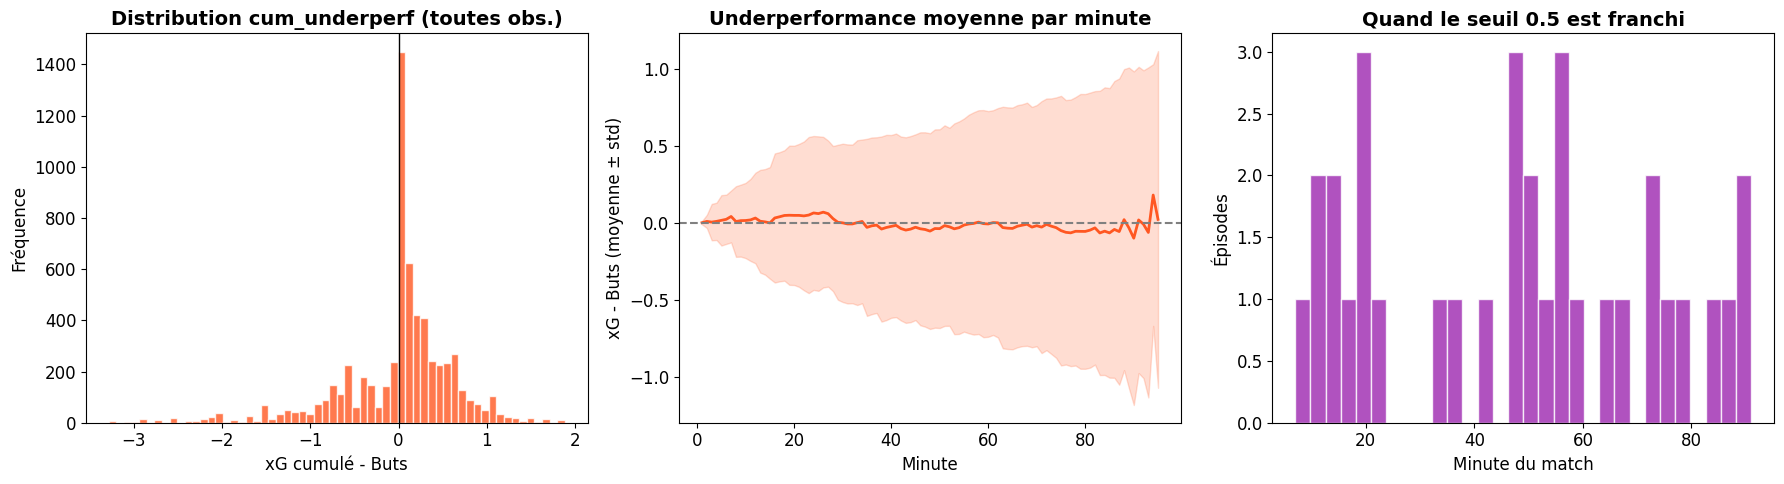

In [17]:
# === Distribution de l'underperformance cumulative ===

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A. Distribution globale de cum_underperf
axes[0].hist(timeline['cum_underperf'], bins=60, color='#FF5722', 
             edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Distribution cum_underperf (toutes obs.)')
axes[0].set_xlabel('xG cumulé - Buts')
axes[0].set_ylabel('Fréquence')

# B. Underperformance par minute du match
minute_stats = timeline.groupby('minute')['cum_underperf'].agg(['mean', 'std'])
axes[1].plot(minute_stats.index, minute_stats['mean'], color='#FF5722', linewidth=2)
axes[1].fill_between(minute_stats.index,
                      minute_stats['mean'] - minute_stats['std'],
                      minute_stats['mean'] + minute_stats['std'],
                      alpha=0.2, color='#FF5722')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('Underperformance moyenne par minute')
axes[1].set_xlabel('Minute')
axes[1].set_ylabel('xG - Buts (moyenne ± std)')

# C. Distribution des minutes de trigger (seuil 0.5)
if len(episodes[episodes['threshold'] == 0.5]) > 0:
    ep05 = episodes[episodes['threshold'] == 0.5]
    axes[2].hist(ep05['trigger_minute'], bins=30, color='#9C27B0', 
                 edgecolor='white', alpha=0.8)
    axes[2].set_title('Quand le seuil 0.5 est franchi')
    axes[2].set_xlabel('Minute du match')
    axes[2].set_ylabel('Épisodes')
else:
    axes[2].text(0.5, 0.5, 'Pas assez\nd\'épisodes', 
                 ha='center', va='center', fontsize=14, transform=axes[2].transAxes)

plt.tight_layout()
plt.savefig('../outputs/figures/02_underperf_distributions.png', 
            dpi=150, bbox_inches='tight')
plt.show()

15:46:19 │ INFO    │ Filtrage fenetre 10min : 700 obs. tronquees supprimees (10.9%)


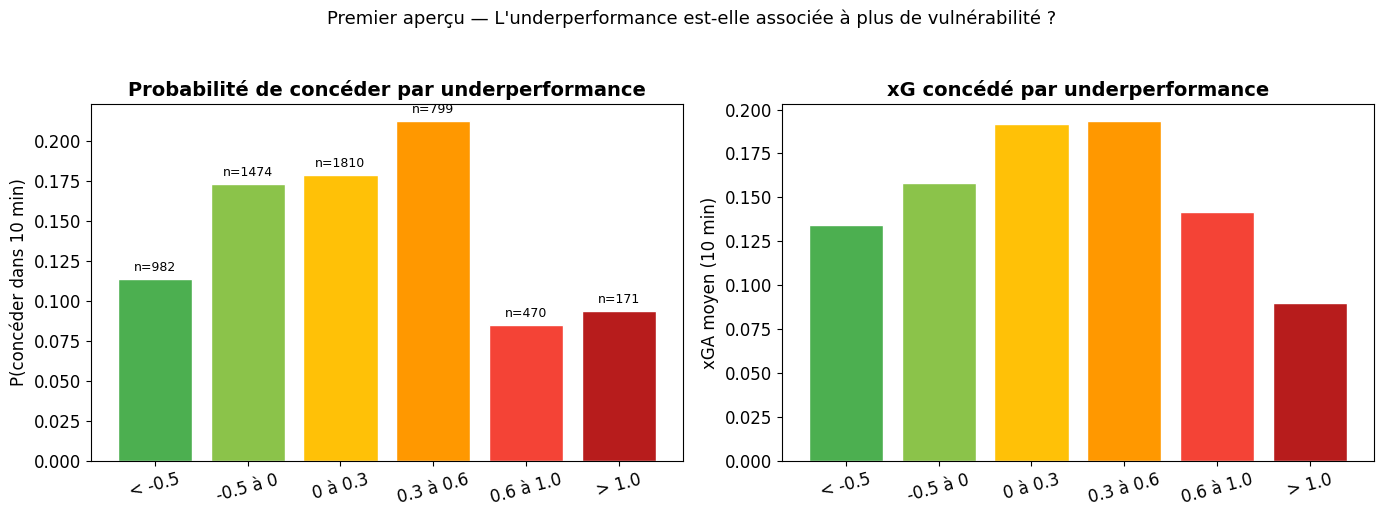


Tableau récapitulatif :
underperf_bin  p_concede  mean_xga  n_obs
       < -0.5   0.114053  0.134268    982
     -0.5 à 0   0.172999  0.158279   1474
      0 à 0.3   0.179006  0.191663   1810
    0.3 à 0.6   0.212766  0.193590    799
    0.6 à 1.0   0.085106  0.141745    470
        > 1.0   0.093567  0.089649    171


In [18]:
# === Premier aperçu de l'hypothèse ===
# P(concéder dans 10 min) en fonction du niveau d'underperformance

# Filtrer les fenêtres complètes
tl_complete = feat.filter_complete_windows(timeline, window=10)

# Bins d'underperformance
tl_complete = tl_complete.copy()
tl_complete['underperf_bin'] = pd.cut(
    tl_complete['cum_underperf'],
    bins=[-np.inf, -0.5, 0, 0.3, 0.6, 1.0, np.inf],
    labels=['< -0.5', '-0.5 à 0', '0 à 0.3', '0.3 à 0.6', '0.6 à 1.0', '> 1.0']
)

# Probabilité de concéder par bin
concede_by_bin = tl_complete.groupby('underperf_bin', observed=True).agg(
    p_concede=('future_conceded_10min', 'mean'),
    mean_xga=('future_xga_10min', 'mean'),
    n_obs=('future_conceded_10min', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# A. P(concéder)
bars = axes[0].bar(range(len(concede_by_bin)), concede_by_bin['p_concede'],
                    color=['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#F44336', '#B71C1C'],
                    edgecolor='white')
axes[0].set_xticks(range(len(concede_by_bin)))
axes[0].set_xticklabels(concede_by_bin['underperf_bin'], rotation=15)
axes[0].set_ylabel('P(concéder dans 10 min)')
axes[0].set_title('Probabilité de concéder par underperformance')

# Annoter avec n
for i, (_, row) in enumerate(concede_by_bin.iterrows()):
    axes[0].text(i, row['p_concede'] + 0.005, f"n={int(row['n_obs'])}",
                 ha='center', fontsize=9)

# B. xGA moyen
axes[1].bar(range(len(concede_by_bin)), concede_by_bin['mean_xga'],
            color=['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#F44336', '#B71C1C'],
            edgecolor='white')
axes[1].set_xticks(range(len(concede_by_bin)))
axes[1].set_xticklabels(concede_by_bin['underperf_bin'], rotation=15)
axes[1].set_ylabel('xGA moyen (10 min)')
axes[1].set_title('xG concédé par underperformance')

plt.suptitle('Premier aperçu — L\'underperformance est-elle associée à plus de vulnérabilité ?',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('../outputs/figures/02_first_look_hypothesis.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Tableau récapitulatif
print("\nTableau récapitulatif :")
print(concede_by_bin.to_string(index=False))

---
## 7. Sauvegarder

In [19]:
# Sauvegarder les timelines
timeline.to_parquet('../data/processed/timelines.parquet', index=False)
print(f"✓ Timelines sauvegardées : {timeline.shape}")

# Sauvegarder les épisodes
episodes.to_parquet('../data/processed/episodes.parquet', index=False)
print(f"✓ Épisodes sauvegardés : {episodes.shape}")

# Sauvegarder les fenêtres complètes (prêtes pour l'analyse)
tl_complete.to_parquet('../data/processed/timelines_complete_10min.parquet', index=False)
print(f"✓ Timelines filtrées (fenêtre 10min complète) : {tl_complete.shape}")

✓ Timelines sauvegardées : (6406, 40)
✓ Épisodes sauvegardés : (107, 29)
✓ Timelines filtrées (fenêtre 10min complète) : (5706, 41)


---
## 8. Résumé & prochaines étapes

### Ce qu'on a fait :
- [x] Timelines minute-par-minute pour chaque match × équipe
- [x] Vérification visuelle sur un match prototype
- [x] Anti look-ahead bias checks
- [x] Épisodes d'underperformance identifiés
- [x] Premier aperçu de l'hypothèse

### Prochaine étape : Phase 3 — Analyse descriptive & tests statistiques
- Tests de comparaison (traité vs contrôle)
- Stratification par score state
- Tests de permutation

→ Ouvrir `03_descriptive_analysis.ipynb`